# Analysis of concreteness/abstractness of texts using Brysbaert's concreteness ratings
## we have multiple elements extracted:
cleantext: The raw text after removing punctuation, expanding contractions, and converting digits to words.

wordcount: The total count of words in the cleaned text string.

brys_score_first: The mean concreteness score calculated using only the words found in the dictionary.

brys_sum_first: The mathematical sum of all concreteness ratings for the words found in the dictionary.

n_missing: The count of tokens that could not be matched to a dictionary entry or a lemma.

n_tokens: The total number of tokens processed from the cleaned text.

n_scored: The number of unique units (unigrams or bigrams) that successfully received a score.

coverage: The ratio of scored units to total tokens, indicating the "density" of rated content.

brys_sample_average: A single constant value representing the mean concreteness score across your entire dataset.

brys_score: The mean concreteness score where missing words are "filled" with the sample average to prevent length bias.

brys_sum_score: The total sum of scores after missing words have been filled with the sample average.

sent_macro_mean: The average of the mean concreteness scores of each individual sentence.

window10_macro_mean: The average of the mean scores calculated for every non-overlapping block of 10 words.

In [9]:
# imports
import pandas as pd
import numpy as np
from pathlib import Path
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import ast

import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_1samp



In [3]:
# loading data

df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditions_with_digit_span_prompt_corrected_brysbaert_concreteness.csv").copy()
OUT_DIR = Path("/mnt/hdd/anatkorol/Imagination_in_translation/analysis/nlp_analysis/comparing_conditions/brysbaeart")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
# keep only some columns for now
df = df[['uid', 'gt', 'session', 'attempt', 'condition', 'prompt_corrected', 'cleantext', 'wordcount',
       'brys_score_first', 'brys_sum_first', 'n_missing', 'n_tokens',
       'n_scored', 'coverage', 'brys_sample_average', 'brys_score',
       'brys_sum_score', 'sent_macro_mean', 'window10_macro_mean']].copy()

## Data Quality Check (Coverage & Tokens)

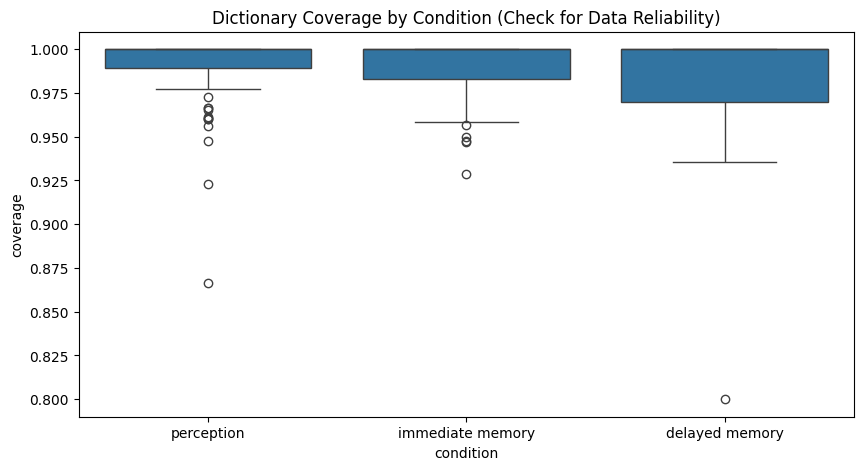

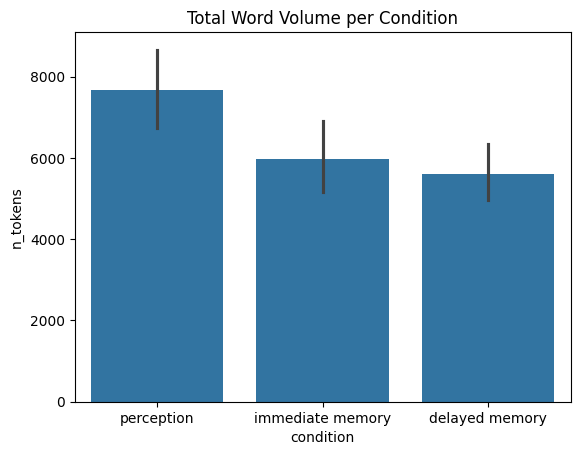

In [7]:
# A. Check Coverage by Condition
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='condition', y='coverage')
plt.title("Dictionary Coverage by Condition (Check for Data Reliability)")
plt.show()

# B. Check Word Count (n_tokens) by Condition
sns.barplot(data=df, x='condition', y='n_tokens', estimator=sum)
plt.title("Total Word Volume per Condition")
plt.show()

# analysis for concreteness scores
## using: 
brys_score: The mean concreteness score where missing words are "filled" with the sample average to prevent length bias.
sent_macro_mean: The average of the mean concreteness scores of each individual sentence.

In [18]:
# C. Statistical Summary Table
summary = df.groupby(['condition', 'attempt'])[['brys_score', 'sent_macro_mean']].mean()
summary

brys_score  sent_macro_mean
condition        attempt                             
delayed memory   1          3.012594         3.027062
                 2          2.957138         2.979647
                 3          2.936187         2.967114
immediate memory 1          3.017264         3.019051
                 2          2.961842         2.977814
                 3          2.933536         2.959329
perception       1          3.038896         3.047959
                 2          2.968281         2.977959
                 3          2.931854         2.939636

### interim conclusion: the two measures are very simiolar so I will be using brys_score alone

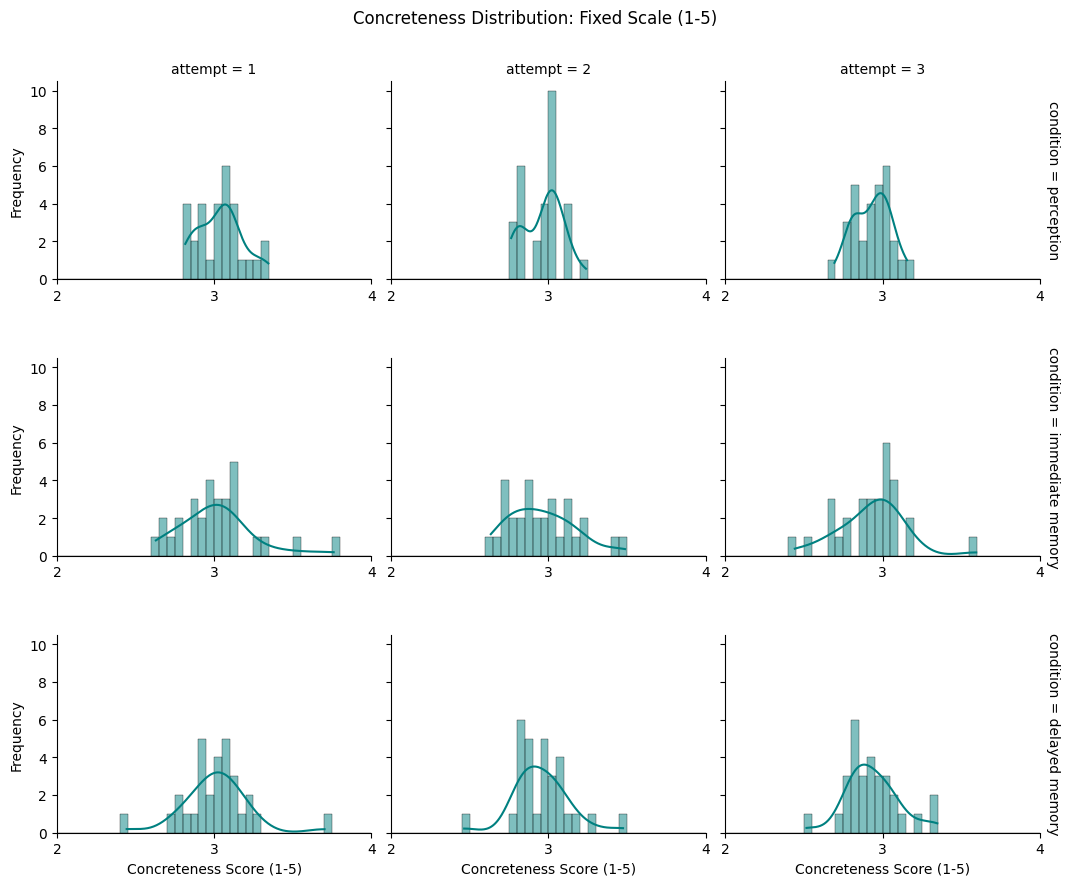

In [17]:
import numpy as np

# 1. Define fixed bins for the whole scale (e.g., width of 0.2)
custom_bins = np.arange(1, 5.2, 0.05) 

# 2. Initialize FacetGrid with sharex=True (to align them) 
# and despine=False to keep the box look if preferred
g = sns.FacetGrid(df, col="attempt", row="condition", margin_titles=True, height=3, aspect=1.2)

# 3. Map the histogram with fixed bins
g.map(sns.histplot, "brys_score", color="teal", kde=True, bins=custom_bins)

# 4. CRITICAL: Set X-axis limits for all and make labels visible on every plot
g.set(xlim=(2, 4), xticks=[2, 3, 4])

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True) # Forces X labels on every subplot

# Add titles and adjust layout
g.set_axis_labels("Concreteness Score (1-5)", "Frequency")
g.fig.subplots_adjust(top=0.9, hspace=0.4) # Added hspace to prevent label overlap
g.fig.suptitle("Concreteness Distribution: Fixed Scale (1-5)")

plt.show()